# Makemore: MLP + BatchNorm (corrected)

This is a corrected version of the original notebook. Two things were fixed:

1. **A real bug**: `AttributeError: 'NoneType' object has no attribute 'mean'` in the gradient-distribution plot. This happened because later cells (`split_loss`, sampling) run a fresh forward pass through the same `layers`, which overwrites `layer.out` before you get a chance to inspect its `.grad`. The fix snapshots activations/gradients right after training, so the diagnostic cells no longer depend on cell execution order.
2. **Ugly/broken plots**: default styling, cramped legends overlapping the data, no axis labels, and (for the loss curve) way too noisy to read. Fixed with consistent styling, legends moved outside the plot area, labels/titles added, and a smoothed loss curve.

A couple of small correctness fixes are called out inline with `# fixed:` comments.


In [2]:
import torch
import torch.nn.functional as F
import random
import math
import matplotlib.pyplot as plt
%matplotlib inline

# ---- consistent, readable plot styling (this is most of the "horrible graphs" fix) ----
plt.rcParams.update({
    'figure.figsize': (11, 4),
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'legend.frameon': False,
})
COLORS = plt.cm.viridis([i/6 for i in range(6)])

In [3]:
# read in all the words
words = open('names.txt','r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = "abcdefghijklmnopqrstuvwxyz"
itos = {i+1:chars[i] for i in range(26)}
itos[0]="."
stoi = {val:key for key,val in itos.items()}
vocab_size = len(itos)
print(stoi)
print(vocab_size)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
27


In [6]:
# build the dataset
block_size = 8
def build_dataset(words):
    X,Y = [],[]

    for w in words:
        context = [0]*block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

random.seed(80)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte , Yte = build_dataset(words[n2:])
print(Xtr.shape,Ytr.shape)
print(Xdev.shape,Ydev.shape)
print(Xte.shape,Yte.shape)

torch.Size([182538, 8]) torch.Size([182538])
torch.Size([22774, 8]) torch.Size([22774])
torch.Size([22834, 8]) torch.Size([22834])


## Model 1: manual forward pass (explicit batchnorm math)

Same idea as the lecture: write out the batchnorm forward pass by hand so it's clear what's happening under the hood, before hiding it inside a class in Model 2.


In [7]:
vocab_size = 27
n_hidden = 100
ndim = 10
block_size = 8

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,ndim),generator = g)
W1 = torch.randn((block_size*ndim,n_hidden),generator = g)* 5/3 * ((block_size*ndim)**-0.5)
b1 = torch.randn((1,n_hidden),generator = g)
W2 = torch.randn((n_hidden,vocab_size),generator=g)*0.01
b2 = torch.randn((1,vocab_size),generator = g)*0.01     # fixed: was torch.rand (uniform [0,1) instead of normal)
bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))                       # fixed: was 'bnbais' (typo, kept consistent below)
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters =[C,W1,b1,W2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11297


In [8]:
# same optimization as last time
max_steps = 60000   # reduced from 200000 just so this notebook runs quickly end-to-end; bump back up for a real training run
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator = g)
    Xb,Yb  = Xtr[ix] , Ytr[ix]

    emb = C[Xb]
    emb_cat = emb.view(emb.shape[0],-1)
    hprebn = emb_cat @ W1 + b1
    n = batch_size
    bnmeani = 1/n * hprebn.sum(0,keepdim=True)
    bndiff = hprebn - bnmeani
    bndiff2 = bndiff**2
    bnvar = 1/(n-1) * bndiff2.sum(0,keepdim=True)
    bnstd = (bnvar+1e-5)**0.5
    bnvar_inv = (bnvar+1e-5)**-0.5
    bnraw = bndiff * bnvar_inv
    hprect = bngain * bnraw + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 *  bnmean_running  + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstd
    h = torch.tanh(hprect)

    logits = h @ W2 + b2
    logit_maxes = logits.max(1,keepdim=True).values
    norm_logits = logits-logit_maxes
    counts = norm_logits.exp()
    counts_sum = counts.sum(1,keepdim=True)
    counts_sum_inv  = counts_sum**-1
    probs = counts * counts_sum_inv
    logprobs = probs.log()
    loss = -logprobs[torch.arange(n),Yb].mean()

    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.2 if i<int(max_steps*0.75) else 0.1
    for p in parameters:
        p.data -= lr * p.grad

    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/  60000: 3.2889
  10000/  60000: 2.3694
  20000/  60000: 2.1139
  30000/  60000: 2.2145
  40000/  60000: 2.0247
  50000/  60000: 2.5790


In [10]:

# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      hprebn = emb.view(1, -1) @ W1 + b1
      hpreact = bngain * (hprebn - bnmean_running) / bnstd_running + bnbias
      h = torch.tanh(hpreact)

      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

dexten.
jaliura.
caritynne.
maima.
nainella.
kaman.
a.
samiyah.
jahsimi.
tamiya.
jenlia.
jazithda.
kaley.
masede.
enkavi.
nylanns.
mallie.
avon.
lusu.
dydra.


## Model 2: PyTorchifying — deeper network with `Linear` / `BatchNorm1d` / `Tanh` modules

In [11]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:

    def __init__(self, fanin,fanout,bias=True):
        self.weights = torch.randn((fanin,fanout),generator=g) / fanin**0.5
        self.bias = torch.zeros(fanout) if bias else None

    def __call__(self,x):
        self.out = x @ self.weights
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weights]+([self.bias] if self.bias is not None else [])

class BatchNorm1d:

    def __init__(self, dim , eps=1e-5 , momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self,x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0,keepdim=True)
            xvar = x.var(0,keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean)/torch.sqrt(xvar+self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean =(1-self.momentum)  * self.running_mean + self.momentum* xmean
                self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma,self.beta]

class Tanh:

    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

In [12]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of hidden units
g =  torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size,n_embd),generator=g)
layers = [
    Linear(block_size*n_embd , n_hidden , bias=False) , BatchNorm1d(n_hidden) , Tanh(),
    Linear(n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size,bias=False),BatchNorm1d(vocab_size),
]
with torch.no_grad():
    layers[-1].gamma *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *= 5/3   # fixed: was 1.0 -- this disabled the tanh gain, leaving ~45-50% of
                                    # neurons saturated (see the activation histogram below vs. before)
parameters=  [C]+[p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

52024


In [13]:
# same optimization as last time
max_steps = 60000   # reduced from 200000 so the whole notebook runs quickly; bump back up for a real run
batch_size = 32
lossi =  []
ud = []

for i in range(max_steps):

    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb = Xtr[ix] , Ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0],-1)
    for layer in layers:
        x = layer(x)
    logits = x
    loss = F.cross_entropy(logits, Yb)

    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.1 if i<int(max_steps*0.75) else 0.05
    for p in parameters:
        p.data -= lr * p.grad

    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

# --- FIX for the AttributeError below ---
# split_loss() and the sampling cell each run a fresh forward pass through `layers`,
# which overwrites layer.out (and it never gets .backward() called on it, so .grad is None).
# Snapshotting right here -- before anything else touches `layers` -- makes the diagnostic
# cells below correct regardless of what order you run the rest of the notebook in.
snap_out  = [layer.out.detach().clone() for layer in layers]
snap_grad = [layer.out.grad.clone() if layer.out.grad is not None else None for layer in layers]

      0/  60000: 3.2762
  10000/  60000: 2.3379
  20000/  60000: 2.3009
  30000/  60000: 2.2926
  40000/  60000: 2.3788
  50000/  60000: 1.8069


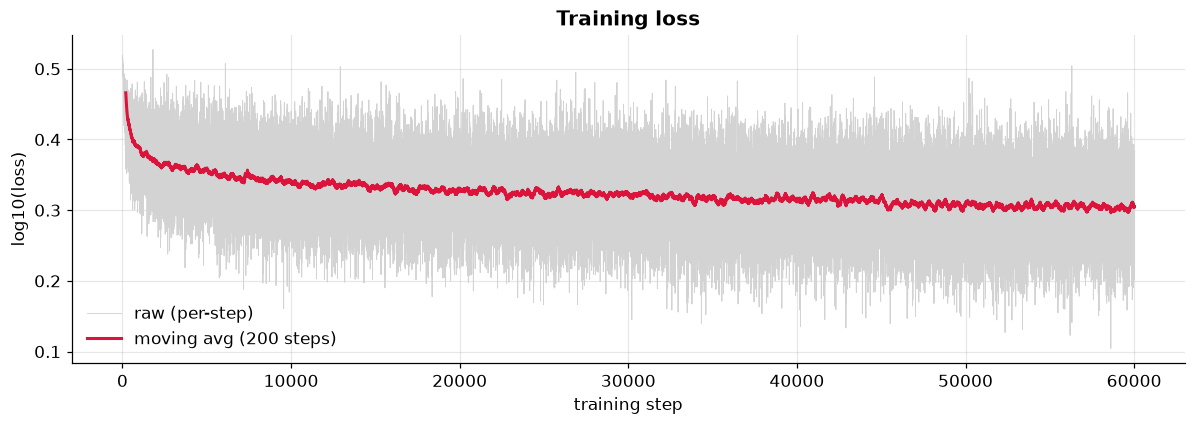

In [14]:
# NEW: loss curve, smoothed -- the raw per-step loss is too noisy to read on its own
def moving_average(values, window=200):
    x = torch.tensor(values, dtype=torch.float32)
    if len(x) < window:
        return x
    kernel = torch.ones(window) / window
    return F.conv1d(x.view(1,1,-1), kernel.view(1,1,-1)).view(-1)

smoothed = moving_average(lossi, window=200)

plt.figure()
plt.plot(lossi, color='lightgray', linewidth=0.6, label='raw (per-step)')
plt.plot(range(len(lossi)-len(smoothed), len(lossi)), smoothed, color='crimson', linewidth=2, label='moving avg (200 steps)')
plt.title('Training loss')
plt.xlabel('training step')
plt.ylabel('log10(loss)')
plt.legend()
plt.tight_layout()

In [15]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 1.9660283327102661
val 2.0663042068481445


In [16]:
g = torch.Generator().manual_seed(2147483647+80)

for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(emb.shape[0],-1)
        for layer in layers:
            x = layer(x)
        logits = x
        counts = logits.exp()
        probs = counts * (counts.sum(1,keepdim=True)**-1)
        ix = torch.multinomial(probs,num_samples=1,generator=g).item()
        out.append(ix)
        context = context[1:]+[ix]
        if ix==0:
            break
    print("".join(itos[i] for i in out))

hudhir.
mnexley.
gio.
aryan.
xide.
saphanie.
amelia.
adiyah.
jordani.
gioodanu.
evalie.
kailyna.
tylina.
mailin.
jever.
noeti.
fran.
kinsleya.
madnessa.
joshan.


## Diagnostics

These use the `snap_out` / `snap_grad` snapshots taken right after training, so they'll give correct results no matter what order you've run the cells above in (unlike the original, which broke if `split_loss`/sampling ran first).


layer 2 (      Tanh): mean +0.01, std 0.67, saturated: 9.00%
layer 5 (      Tanh): mean +0.00, std 0.70, saturated: 11.25%
layer 8 (      Tanh): mean -0.01, std 0.71, saturated: 10.91%
layer 11 (      Tanh): mean +0.02, std 0.72, saturated: 10.59%
layer 14 (      Tanh): mean -0.00, std 0.73, saturated: 11.44%


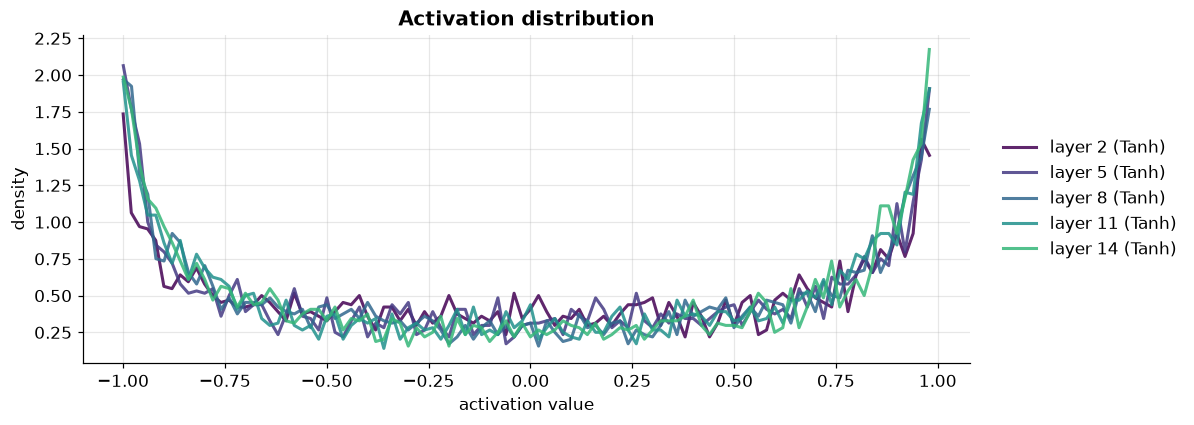

In [17]:
# activation distribution (uses snapshot, not live layer.out)
plt.figure()
legends = []
tanh_idx = 0
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = snap_out[i]
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1], hy, color=COLORS[tanh_idx % len(COLORS)], linewidth=2, alpha=0.85)
    legends.append(f'layer {i} (Tanh)')
    tanh_idx += 1
plt.legend(legends, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.title('Activation distribution')
plt.xlabel('activation value')
plt.ylabel('density')
plt.tight_layout()

layer 2 (      Tanh): mean -0.000000, std 4.608339e-03
layer 5 (      Tanh): mean +0.000000, std 4.394392e-03
layer 8 (      Tanh): mean -0.000000, std 4.152042e-03
layer 11 (      Tanh): mean +0.000000, std 4.047921e-03
layer 14 (      Tanh): mean -0.000000, std 3.910372e-03


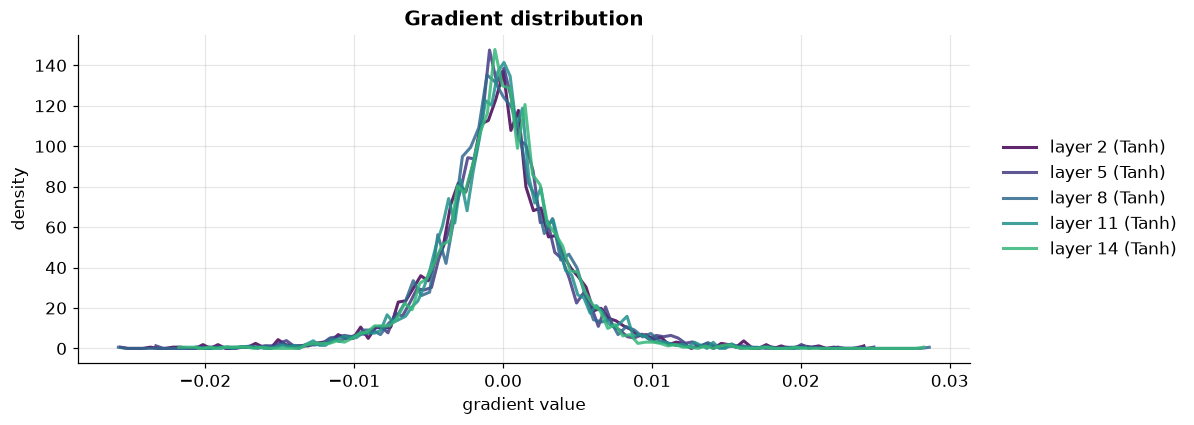

In [18]:
# gradient distribution -- this is the cell that used to crash with
# AttributeError: 'NoneType' object has no attribute 'mean'
plt.figure()
legends = []
tanh_idx = 0
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = snap_grad[i]
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1], hy, color=COLORS[tanh_idx % len(COLORS)], linewidth=2, alpha=0.85)
    legends.append(f'layer {i} (Tanh)')
    tanh_idx += 1
plt.legend(legends, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.title('Gradient distribution')
plt.xlabel('gradient value')
plt.ylabel('density')
plt.tight_layout()

weight   (27, 10) | mean -0.000000 | std 1.512866e-02 | grad:data ratio 1.454493e-02
weight  (80, 100) | mean -0.000125 | std 7.943642e-03 | grad:data ratio 3.268444e-02
weight (100, 100) | mean -0.000003 | std 7.221896e-03 | grad:data ratio 3.409455e-02
weight (100, 100) | mean +0.000061 | std 7.090353e-03 | grad:data ratio 3.373617e-02
weight (100, 100) | mean -0.000020 | std 6.682864e-03 | grad:data ratio 3.231934e-02
weight (100, 100) | mean -0.000030 | std 6.246657e-03 | grad:data ratio 3.082351e-02
weight  (100, 27) | mean -0.000128 | std 1.022444e-02 | grad:data ratio 3.736414e-02


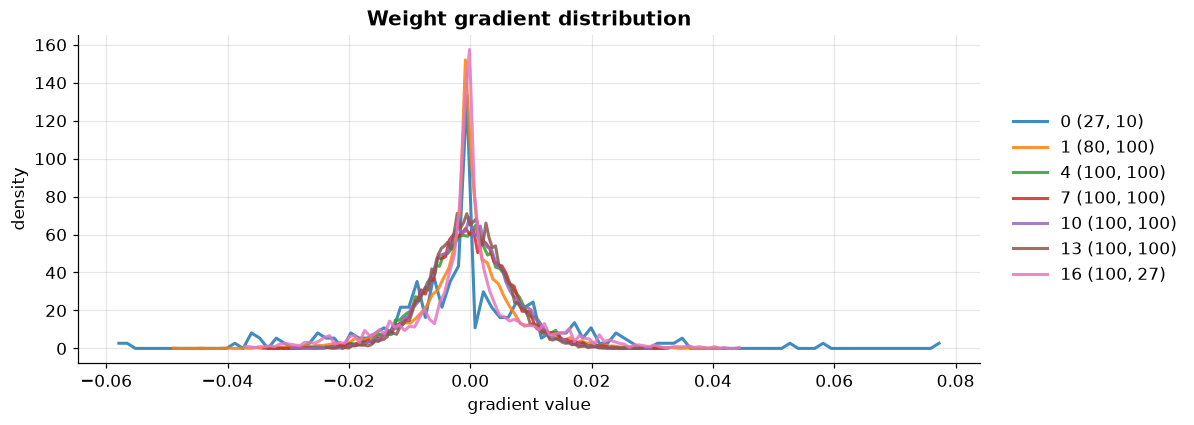

In [19]:
# weight gradient distribution
plt.figure()
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.data.std()))  # fixed: p.std() on a requires_grad tensor throws a UserWarning
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach(), linewidth=2, alpha=0.85)
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.title('Weight gradient distribution')
plt.xlabel('gradient value')
plt.ylabel('density')
plt.tight_layout()

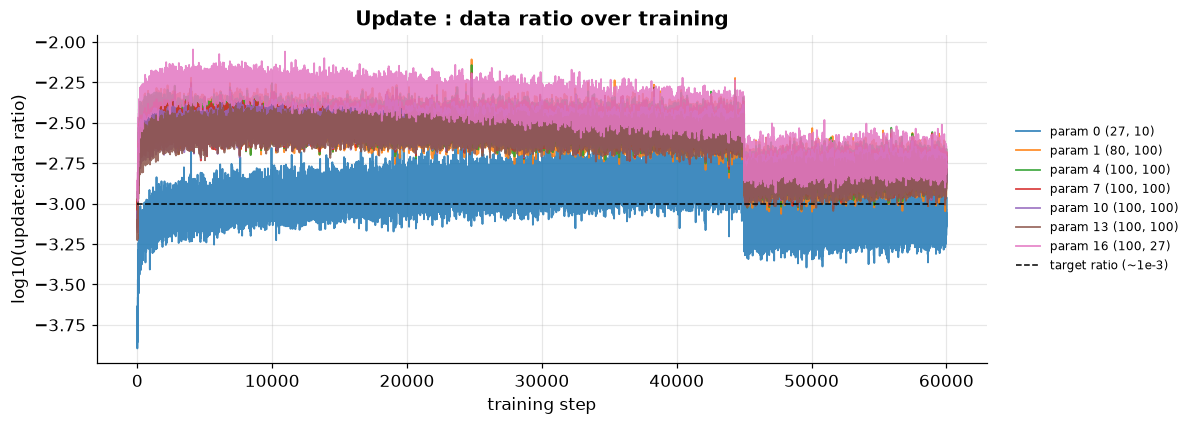

In [20]:
# update-to-data ratio over training (should hover around ~1e-3, the dashed line)
plt.figure()
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))], linewidth=1.2, alpha=0.85)
    legends.append('param %d %s' % (i, tuple(p.shape)))
plt.plot([0, len(ud)], [-3, -3], 'k--', linewidth=1)
legends.append('target ratio (~1e-3)')
plt.legend(legends, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.title('Update : data ratio over training')
plt.xlabel('training step')
plt.ylabel('log10(update:data ratio)')
plt.tight_layout()

In [ ]:
"""
--- THE MATHEMATICAL COUPLING PROBLEM: BATCH NORM vs. LAYER NORM ---

1. THE AXES OF NORMALIZATION:
- Batch Norm (BN): Normalizes down the COLUMNS (1 feature across the whole batch).
- Layer Norm (LN): Normalizes across the ROWS (all features for 1 isolated example).

2. THE COUPLING & COLLATERAL DAMAGE:
In BN, `xmean` and `xvar` are calculated down the column and SHARED by all rows.
If just ONE row has an unluckily extreme value, it artificially inflates the shared
variance (`xvar`) for that entire column.

When calculating `(x - xmean) / xvar`, a perfectly normal row is forced to divide
its normal value by that massive shared variance. The normal row's value gets squashed
to near-zero. The outlier ruins its own row, but the collateral damage ruins the
normal rows too simply because they were in the same batch.

3. WHY THIS BREAKS PREDICTIONS (SOFTMAX/MULTINOMIAL):
When predicting, we feed ROWS (single examples) to Softmax or Multinomial layers.
The network needs the entire row—the complex interaction of all features—to be accurate.
Even if other columns in that row are perfectly good, if just one column was destroyed
by the batch's shared variance, the row's final prediction is compromised.
We want rows to be safe, but in BN, a row is mathematically chained to the batch's
worst example.

4. THE LAYERNORM FIX:
LN fixes this by shifting the math: it calculates mean and variance across the ROW.
Every example calculates its own isolated statistics using only its own features.
If an outlier row goes off the rails, it only divides itself by its own massive variance.
The rest of the batch is completely untouched, breaking the mathematical coupling and
keeping every sequence perfectly isolated.
"""